# 🎓 Student Placement Prediction – EDA & Baseline Models
### Exploring the synthetic 100K student placement dataset
**Dataset features:** Academic scores, technical skills, internships, projects → Placement status & Salary


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
df = pd.read_csv('/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv')
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [3]:
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nPlacement Rate:", round(df['placement_status'].mean() * 100, 2), "%")
print("Avg Salary (Placed):", round(df['salary_package_lpa'].mean(), 2), "LPA")
df.describe()


Shape: (100000, 18)

Missing Values:
 branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

Placement Rate: 68.47 %
Avg Salary (Placed): 17.31 LPA


,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


## 📊 Exploratory Data Analysis


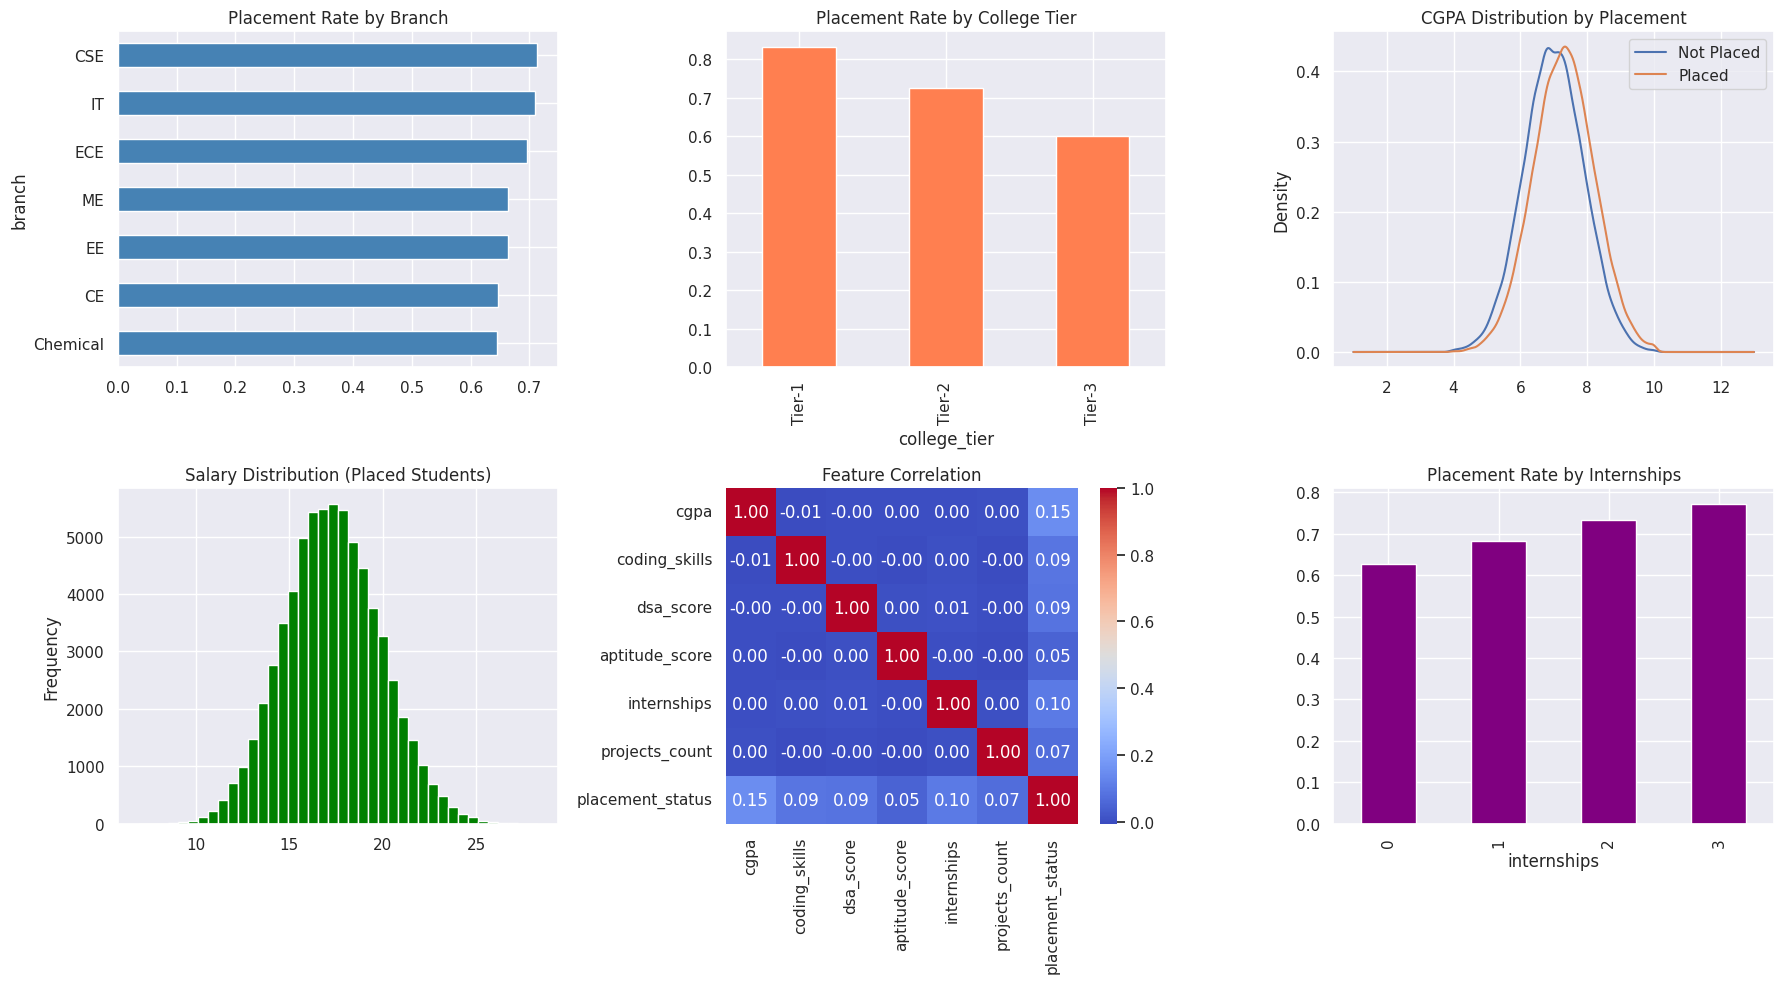

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Placement by branch
branch_rate = df.groupby('branch')['placement_status'].mean().sort_values()
branch_rate.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Placement Rate by Branch')

# Placement by tier
tier_rate = df.groupby('college_tier')['placement_status'].mean()
tier_rate.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Placement Rate by College Tier')

# CGPA distribution
df.groupby('placement_status')['cgpa'].plot(kind='kde', ax=axes[0,2], legend=True)
axes[0,2].set_title('CGPA Distribution by Placement')
axes[0,2].legend(['Not Placed', 'Placed'])

# Salary distribution
df['salary_package_lpa'].dropna().plot(kind='hist', bins=40, ax=axes[1,0], color='green')
axes[1,0].set_title('Salary Distribution (Placed Students)')

# Correlation heatmap
num_cols = ['cgpa','coding_skills','dsa_score','aptitude_score','internships','projects_count','placement_status']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', ax=axes[1,1], cmap='coolwarm')
axes[1,1].set_title('Feature Correlation')

# Internships vs placement
df.groupby('internships')['placement_status'].mean().plot(kind='bar', ax=axes[1,2], color='purple')
axes[1,2].set_title('Placement Rate by Internships')

plt.tight_layout()
plt.show()


## 🤖 Baseline Classification Models
Predicting `placement_status` using Logistic Regression and Random Forest


In [5]:
features = ['cgpa','coding_skills','dsa_score','aptitude_score',
            'communication_skills','ml_knowledge','system_design',
            'internships','projects_count','certifications',
            'hackathons','backlogs']

X = df[features]
y = df['placement_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Logistic Regression ===")
print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(classification_report(y_test, lr_pred))

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(classification_report(y_test, rf_pred))


=== Logistic Regression ===
Accuracy: 0.6906
              precision    recall  f1-score   support

           0       0.55      0.14      0.22      6335
           1       0.70      0.95      0.81     13665

    accuracy                           0.69     20000
   macro avg       0.63      0.54      0.51     20000
weighted avg       0.65      0.69      0.62     20000

=== Random Forest ===
Accuracy: 0.6844
              precision    recall  f1-score   support

           0       0.51      0.15      0.23      6335
           1       0.70      0.93      0.80     13665

    accuracy                           0.68     20000
   macro avg       0.60      0.54      0.51     20000
weighted avg       0.64      0.68      0.62     20000



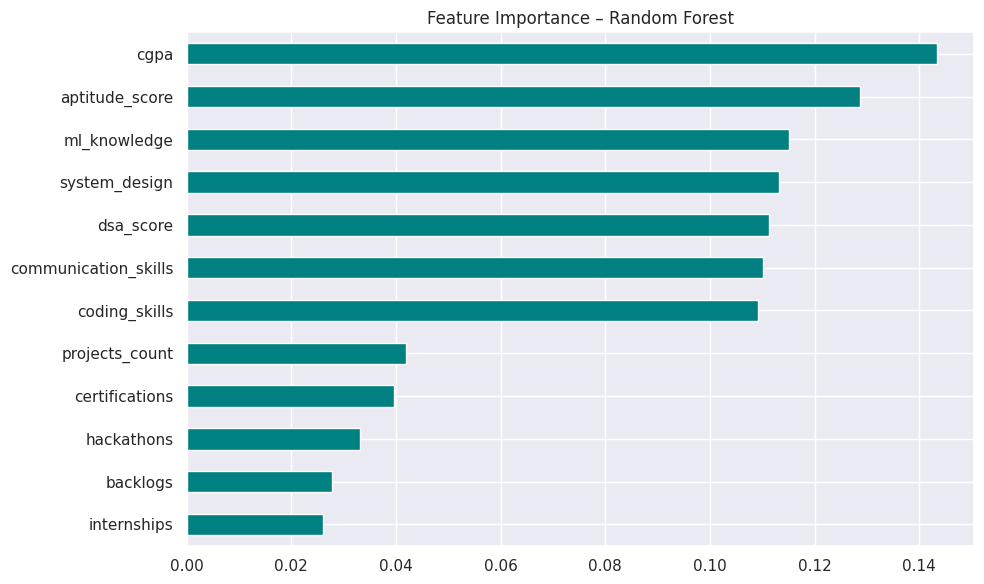

In [6]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
feat_imp.plot(kind='barh', figsize=(10, 6), color='teal')
plt.title('Feature Importance – Random Forest')
plt.tight_layout()
plt.show()


## ✅ Next Steps
- Try XGBoost / LightGBM for better accuracy
- Build a regression model to predict `salary_package_lpa`
- Perform fairness analysis across `branch` and `college_tier`
- Tune hyperparameters with GridSearchCV
